<a href="https://colab.research.google.com/github/sametgumusaydin/data_mining-AI/blob/main/Data_mining_Regularization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regularization nedir?

Linear Regressionda şu sorunlar oluşabilir:

-Overfitting

-Çok büyük katsayılar

-Gürültüye aşırı duyarlılık

Bu noktada Çözüm: Regularization (düzenlileştirme)

şöyleki:
Modele ceza ekleyerek daha basit ve genelleştirilebilir hale getirmektir.

RIDGE REGRESSION (L2)--Formülü :

Loss=∑(y-y^)² + λ∑wi²

 Mantık :

Hata (MSE) + katsayıların kare cezası

büyük katsayılar küçültülür

Özellik:

-tüm featurelar kalır

-katsayılar küçülür ama sıfır olmaz

-multicollinearity için çok iyi


Etkisi ne olur  ???

** model daha stabil olur

** aşırı öğrenme azalır


LASSO REGRESSION (L1) Formülü:


Loss=∑(y-y^)² + λ∑∣wi∣

 Mantık
mutlak değer cezası
bazı katsayıları sıfıra indirir

Özellik

-feature selection yapar
-gereksiz değişkenleri siler


Etkisi ne olur ????


** model sadeleşir

** yorumlanabilirlik artar

**===??Geometrik fark (çok önemli):===**

Ridge → daire (smooth shrink)

Lasso → köşeli (sıfırlama eğilimi)


***bu yüzden Lasso bazı katsayıları 0 yapar

Ridge küçültür, Lasso sıfırlar.


Ne zaman hangisi?

****** Ridge kullan:

-featurelar önemliyse

-veri çoksa

-stabil model isteniyorsa

******* Lasso kullan:

-feature sayısı fazlaysa

-gereksiz değişken varsa

-model sade olsun istiyorsan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

# Veri
data = {
    "gelir": [32000, 45000, 58000, 62000, 29000, 70000, 52000, 81000, 47000, 90000,
              61000, 38000, 55000, 73000, 34000, 68000, 49000, 76000, 43000, 64000,
              57000, 36000, 85000, 51000],
    "yas": [22, 25, 27, 30, 21, 35, 28, 40, 26, 45,
            31, 24, 29, 38, 23, 34, 27, 39, 25, 33,
            30, 22, 42, 28],
    "mevcut_borc": [18000, 12000, 10000, 9000, 15000, 8000, 14000, 5000, 11000, 4000,
                    9500, 17000, 13000, 6000, 16000, 7000, 12500, 5500, 14500, 8500,
                    10000, 17500, 4500, 13500],
    "kredi_puani": [480, 520, 610, 640, 450, 700, 590, 760, 560, 790,
                    650, 500, 600, 720, 490, 690, 570, 740, 530, 660,
                    620, 470, 780, 585]
}

df = pd.DataFrame(data)

# Bağımsız değişkenler
X = df[["gelir", "yas", "kredi_puani"]]

# Bağımlı değişken
y = df["mevcut_borc"]

# Ölçekleme (ÇOK ÖNEMLİ!)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================
# RIDGE
# =====================
ridge = Ridge(alpha=1.0)
ridge.fit(X_scaled, y)
y_pred_ridge = ridge.predict(X_scaled)

# =====================
# LASSO
# =====================
lasso = Lasso(alpha=1.0)
lasso.fit(X_scaled, y)
y_pred_lasso = lasso.predict(X_scaled)

# =====================
# PERFORMANS
# =====================
print("RIDGE MSE:", mean_squared_error(y, y_pred_ridge))
print("RIDGE R2:", r2_score(y, y_pred_ridge))

print("\nLASSO MSE:", mean_squared_error(y, y_pred_lasso))
print("LASSO R2:", r2_score(y, y_pred_lasso))

# =====================
# KATSAYILAR
# =====================
print("\nRIDGE Katsayılar:", ridge.coef_)
print("LASSO Katsayılar:", lasso.coef_)

RIDGE MSE: 1515794.716998033
RIDGE R2: 0.9143265864987865

LASSO MSE: 1437400.312810691
LASSO R2: 0.9187574742244178

RIDGE Katsayılar: [-1771.5970192   -522.69960228 -1675.05593583]
LASSO Katsayılar: [-2944.75470739   880.47531613 -1954.15718627]


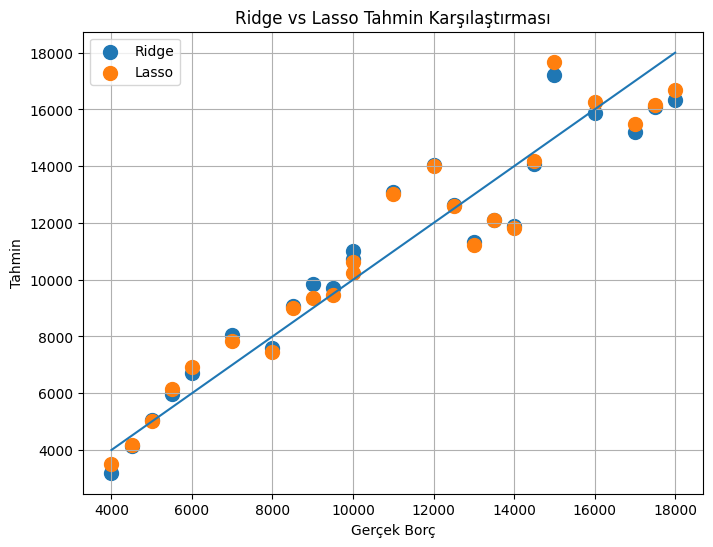

In [2]:
plt.figure(figsize=(8,6))

plt.scatter(y, y_pred_ridge, label="Ridge", s=100)
plt.scatter(y, y_pred_lasso, label="Lasso", s=100)

plt.plot([min(y), max(y)], [min(y), max(y)])

plt.xlabel("Gerçek Borç")
plt.ylabel("Tahmin")
plt.title("Ridge vs Lasso Tahmin Karşılaştırması")

plt.legend()
plt.grid(True)
plt.show()

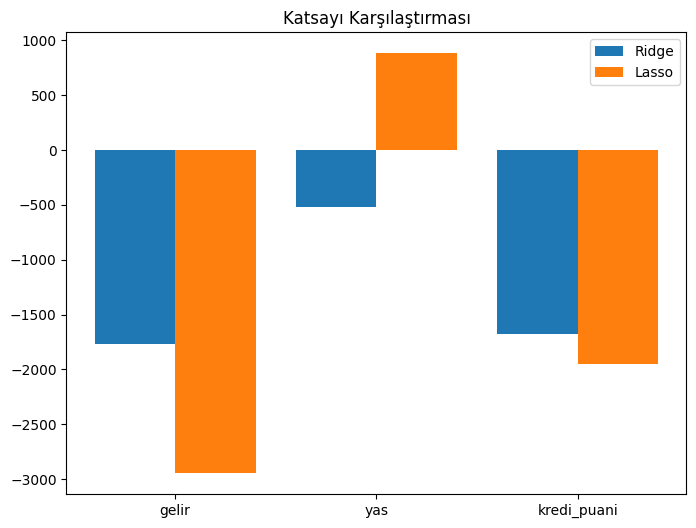

In [3]:
import numpy as np

labels = ["gelir", "yas", "kredi_puani"]

x = np.arange(len(labels))

plt.figure(figsize=(8,6))

plt.bar(x - 0.2, ridge.coef_, width=0.4, label="Ridge")
plt.bar(x + 0.2, lasso.coef_, width=0.4, label="Lasso")

plt.xticks(x, labels)
plt.title("Katsayı Karşılaştırması")
plt.legend()

plt.show()

SONUÇ:

Ridge regresyon, katsayıların büyüklüğünü sınırlayarak modelin varyansını azaltırken, Lasso regresyon bazı katsayıları sıfıra indirerek modelde değişken seçimi gerçekleştirmektedir. Bu yönüyle Lasso, yüksek boyutlu veri setlerinde daha sade ve yorumlanabilir modeller üretmektedir.

Overfitting ilişkisi :

-Ridge → overfitting azaltır

-Lasso → overfitting + feature seçimi

***** Ridge katsayıları küçültür, Lasso gereksiz olanları sıfıra indirir.